In [17]:
## Data pre-processing and feature engineering.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load Dataset
df = pd.read_csv(r'C:\Users\Soumya_SRB\Desktop\Loan_Prediction_dataset\train_ctrUa4K.csv')  # Load Prediction Dataset

# 2. Basic Cleaning (Handling Missing Values)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# 3. Feature Engineering (Mandatory Project Requirement)
# Create Total Income and Income-to-Loan Ratio
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']

# 4. Encoding Categorical Variables
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                    'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode Target Variable (Y = 1 for Approved, N = 0 for Default/Rejected)
le = LabelEncoder()
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

# Drop ID column
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# 5. Fixed 80:20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 6. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete! Train shape:", X_train.shape, "Test shape:", X_test.shape)

Data preprocessing complete! Train shape: (491, 16) Test shape: (123, 16)


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# List to store comparison metrics
results = []

def evaluate_and_store(model_name, model, X_test_data, y_true):
    y_pred = model.predict(X_test_data)
    y_probs = model.predict_proba(X_test_data)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs) if y_probs is not None else 0.0
    
    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    print(f"=== {model_name} ===")
    print(f"Accuracy : {acc:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("-" * 50)

In [19]:
from sklearn.linear_model import LogisticRegression

# Train Model 1
m1_logistic = LogisticRegression(random_state=42)
m1_logistic.fit(X_train_scaled, y_train)

# Call the function to print results
evaluate_and_store("1. Logistic Regression", m1_logistic, X_test_scaled, y_test)

=== 1. Logistic Regression ===
Accuracy : 0.8618 | Recall: 0.9882 | Precision: 0.8400
Confusion Matrix:
 [[22 16]
 [ 1 84]]
--------------------------------------------------


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# Create Polynomial Features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train Model 2
m2_poly = LogisticRegression(random_state=42, max_iter=1000)
m2_poly.fit(X_train_poly, y_train)

# Evaluate Model 2
evaluate_and_store("2. Polynomial Logistic (deg=2)", m2_poly, X_test_poly, y_test)

=== 2. Polynomial Logistic (deg=2) ===
Accuracy : 0.7398 | Recall: 0.8353 | Precision: 0.7978
Confusion Matrix:
 [[20 18]
 [14 71]]
--------------------------------------------------


In [21]:
from sklearn.tree import DecisionTreeClassifier

# Train Model 3
m3_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
m3_tree.fit(X_train, y_train)  # Decision Trees use unscaled data

# Evaluate Model 3
evaluate_and_store("3. Decision Tree", m3_tree, X_test, y_test)

=== 3. Decision Tree ===
Accuracy : 0.8537 | Recall: 0.9647 | Precision: 0.8454
Confusion Matrix:
 [[23 15]
 [ 3 82]]
--------------------------------------------------


In [22]:
from sklearn.ensemble import RandomForestClassifier

# Train Model 4
m4_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
m4_rf.fit(X_train, y_train)

# Evaluate Model 4
evaluate_and_store("4. Random Forest", m4_rf, X_test, y_test)

=== 4. Random Forest ===
Accuracy : 0.8699 | Recall: 0.9882 | Precision: 0.8485
Confusion Matrix:
 [[23 15]
 [ 1 84]]
--------------------------------------------------


In [23]:
# Display comparison table
comparison_df = pd.DataFrame(results)
print("=== FINAL MODEL COMPARISON TABLE ===")
display(comparison_df)

=== FINAL MODEL COMPARISON TABLE ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1. Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8511
1,2. Polynomial Logistic (deg=2),0.7398,0.7978,0.8353,0.8161,0.7279
2,3. Decision Tree,0.8537,0.8454,0.9647,0.9011,0.7814
3,4. Random Forest,0.8699,0.8485,0.9882,0.9130,0.8879


In [24]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(m1_logistic, 'models/model_1_logistic.pkl')
joblib.dump(m2_poly, 'models/model_2_polynomial.pkl')
joblib.dump(m3_tree, 'models/model_3_decision_tree.pkl')
joblib.dump(m4_rf, 'models/model_4_random_forest.pkl')

print("All 4 models successfully saved in 'models/' directory!")

All 4 models successfully saved in 'models/' directory!


In [25]:
import joblib

# Load your saved model back into Python
loaded_model = joblib.load('models/model_1_logistic.pkl')

# Test making predictions with the loaded model
predictions = loaded_model.predict(X_test_scaled)
print("Model loaded successfully!")

Model loaded successfully!


In [26]:
import pandas as pd

# Create and display the summary DataFrame
comparison_df = pd.DataFrame(results)
display(comparison_df)
print(comparison_df.to_string())

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1. Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8511
1,2. Polynomial Logistic (deg=2),0.7398,0.7978,0.8353,0.8161,0.7279
2,3. Decision Tree,0.8537,0.8454,0.9647,0.9011,0.7814
3,4. Random Forest,0.8699,0.8485,0.9882,0.9130,0.8879


                            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0          1. Logistic Regression    0.8618     0.8400  0.9882    0.9081   0.8511
1  2. Polynomial Logistic (deg=2)    0.7398     0.7978  0.8353    0.8161   0.7279
2                3. Decision Tree    0.8537     0.8454  0.9647    0.9011   0.7814
3                4. Random Forest    0.8699     0.8485  0.9882    0.9130   0.8879


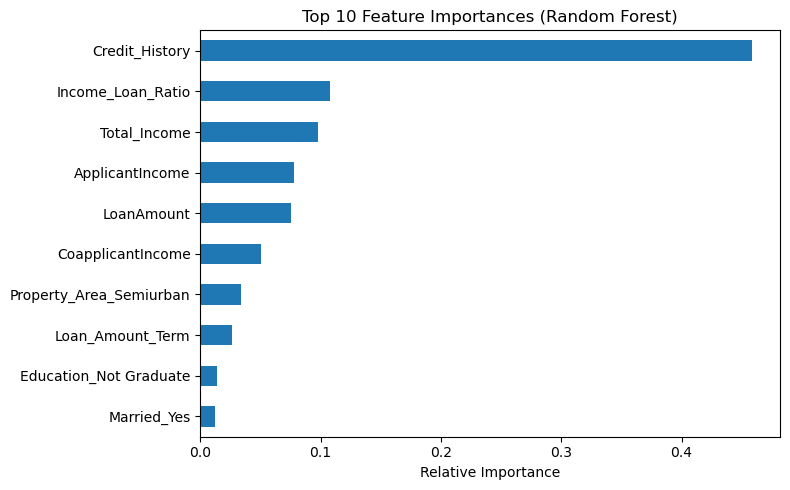

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from Random Forest
importances = pd.Series(m4_rf.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', figsize=(8, 5))

plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
%%writefile .gitignore
.ipynb_checkpoints/
__pycache__/
*.pyc

Writing .gitignore
